# PICO Extraction Pipeline

This notebook implements one focused pipeline:

1. Sentence segmentation
2. Sentence-level classification
3. Token-level entity extraction
4. Post-processing and normalization
5. PICO table construction
6. Evaluation with precision, recall, and F1

Comparator is not directly gold-labeled in this EBM-NLP copy, so it is inferred in post-processing.


## 1. Setup


In [1]:
from __future__ import annotations

import random
import re
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import classification_report, precision_recall_fscore_support
from transformers import (
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)


DATA_DIR = Path("/Users/priyanshugurjar/Downloads/AI AND TEXT/ebm_nlp_2_00")
DOCS_DIR = DATA_DIR / "documents"
ANN_DIR = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels"

SEED = 13
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" 
print("Data dir:", DATA_DIR)
print("Device:", DEVICE)


Data dir: /Users/priyanshugurjar/Downloads/AI AND TEXT/ebm_nlp_2_00
Device: cuda


## 2. Data Loading


In [2]:
@dataclass
class Document:
    doc_id: str
    tokens: List[str]
    tags: List[str]


def get_doc_ids(label_type: str, split: str) -> List[str]:
    if split == "test":
        split = "test/gold"
    folder = ANN_DIR / label_type / split
    return sorted(p.name.split(".")[0] for p in folder.glob("*.AGGREGATED.ann"))


def load_tokens(doc_id: str) -> List[str]:
    with open(DOCS_DIR / f"{doc_id}.tokens", "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]


def load_labels(doc_id: str, label_type: str, split: str) -> List[str]:
    if split == "test":
        split = "test/gold"
    ann_path = ANN_DIR / label_type / split / f"{doc_id}.AGGREGATED.ann"
    with open(ann_path, "r", encoding="utf-8") as f:
        raw = [line.strip() for line in f]
    return hierarchical_to_bio(raw)


def hierarchical_to_bio(raw_tags: Sequence[str]) -> List[str]:
    bio = []
    prev = 0
    for tag in raw_tags:
        value = int(tag)
        if value == 0:
            bio.append("O")
        elif prev == 0:
            bio.append("B")
        else:
            bio.append("I")
        prev = value
    return bio


def load_dataset(label_type: str, split: str) -> List[Document]:
    docs = []
    for doc_id in get_doc_ids(label_type, split):
        docs.append(Document(doc_id=doc_id, tokens=load_tokens(doc_id), tags=load_labels(doc_id, label_type, split)))
    return docs


participants_train = load_dataset("participants", "train")
interventions_train = load_dataset("interventions", "train")
outcomes_train = load_dataset("outcomes", "train")

participants_test = load_dataset("participants", "test")
interventions_test = load_dataset("interventions", "test")
outcomes_test = load_dataset("outcomes", "test")

print("participants train/test:", len(participants_train), len(participants_test))
print("interventions train/test:", len(interventions_train), len(interventions_test))
print("outcomes train/test:", len(outcomes_train), len(outcomes_test))


participants train/test: 4609 189
interventions train/test: 4746 187
outcomes train/test: 4681 190


## 3. Sentence Segmentation


In [3]:
@dataclass
class SentenceExample:
    doc_id: str
    sent_idx: int
    tokens: List[str]
    tags: List[str]
    orig_indices: List[int]
    label: str


SENT_END = {".", "!", "?"}


def split_tokens_into_sentences(tokens: Sequence[str], tags: Sequence[str]) -> List[Tuple[List[str], List[str], List[int]]]:
    chunks = []
    cur_tokens, cur_tags, cur_idx = [], [], []
    for idx, (tok, tag) in enumerate(zip(tokens, tags)):
        cur_tokens.append(tok)
        cur_tags.append(tag)
        cur_idx.append(idx)
        if tok in SENT_END:
            chunks.append((cur_tokens, cur_tags, cur_idx))
            cur_tokens, cur_tags, cur_idx = [], [], []
    if cur_tokens:
        chunks.append((cur_tokens, cur_tags, cur_idx))
    return chunks


def dominant_label(sent_labels: Dict[str, List[str]]) -> str | None:
    counts = {
        "participants": sum(tag != "O" for tag in sent_labels["participants"]),
        "interventions": sum(tag != "O" for tag in sent_labels["interventions"]),
        "outcomes": sum(tag != "O" for tag in sent_labels["outcomes"]),
    }

    best_name = max(counts, key=counts.get)
    best_count = counts[best_name]

    if best_count == 0:
        return None

    return {"participants": "P", "interventions": "I", "outcomes": "O"}[best_name]



def build_sentence_examples(split: str) -> List[SentenceExample]:
    p_docs = {d.doc_id: d for d in load_dataset("participants", split)}
    i_docs = {d.doc_id: d for d in load_dataset("interventions", split)}
    o_docs = {d.doc_id: d for d in load_dataset("outcomes", split)}
    common_ids = sorted(set(p_docs) & set(i_docs) & set(o_docs))

    examples = []
    for doc_id in common_ids:
        tokens = p_docs[doc_id].tokens
        sent_chunks = split_tokens_into_sentences(tokens, p_docs[doc_id].tags)
        p_chunks = split_tokens_into_sentences(tokens, p_docs[doc_id].tags)
        i_chunks = split_tokens_into_sentences(tokens, i_docs[doc_id].tags)
        o_chunks = split_tokens_into_sentences(tokens, o_docs[doc_id].tags)

        for sent_idx, ((sent_tokens, _, indices), (_, p_tags, _), (_, i_tags, _), (_, o_tags, _)) in enumerate(zip(sent_chunks, p_chunks, i_chunks, o_chunks)):
            label = dominant_label({
                "participants": p_tags,
                "interventions": i_tags,
                "outcomes": o_tags,
            })
            if label is None:
                continue
            target_tags = {"P": p_tags, "I": i_tags, "O": o_tags}[label]
            examples.append(
                SentenceExample(
                    doc_id=doc_id,
                    sent_idx=sent_idx,
                    tokens=sent_tokens,
                    tags=target_tags,
                    orig_indices=indices,
                    label=label,
                )
            )
    return examples


sentence_train = build_sentence_examples("train")
sentence_test = build_sentence_examples("test")

print("Sentence train size:", len(sentence_train))
print("Sentence test size:", len(sentence_test))
print("Sentence labels:", Counter(x.label for x in sentence_train))



Sentence train size: 35669
Sentence test size: 1530
Sentence labels: Counter({'O': 16785, 'I': 11838, 'P': 7046})


## 4. Sentence-Level Classification


In [4]:
SENT_LABELS = ["P", "I", "O"]
SENT_LABEL_TO_ID = {label: i for i, label in enumerate(SENT_LABELS)}
SENT_ID_TO_LABEL = {i: label for label, i in SENT_LABEL_TO_ID.items()}
SENT_MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"


def sentence_examples_to_dataset(examples: Sequence[SentenceExample]) -> Dataset:
    return Dataset.from_dict(
        {
            "doc_id": [x.doc_id for x in examples],
            "sent_idx": [x.sent_idx for x in examples],
            "text": [" ".join(x.tokens) for x in examples],
            "label": [SENT_LABEL_TO_ID[x.label] for x in examples],
        }
    )


def tokenize_sentence_batch(tokenizer, batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )


def compute_sentence_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0,
    )
    acc = (preds == labels).mean()
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": acc,
    }


def sample_sentence_examples(examples, n_per_label=200, seed=13):
    rng = random.Random(seed)
    grouped = {"P": [], "I": [], "O": []}

    for ex in examples:
        grouped[ex.label].append(ex)

    sampled = []
    for label in ["P", "I", "O"]:
        group = grouped[label][:]
        rng.shuffle(group)
        sampled.extend(group[:min(n_per_label, len(group))])

    rng.shuffle(sampled)
    return sampled


small_sentence_train = sample_sentence_examples(sentence_train, n_per_label=200, seed=13)
small_sentence_test = sample_sentence_examples(sentence_test, n_per_label=100, seed=13)

print("small train:", len(small_sentence_train))
print("small test:", len(small_sentence_test))
print("train labels:", Counter(x.label for x in small_sentence_train))
print("test labels:", Counter(x.label for x in small_sentence_test))

train_sent_ds = sentence_examples_to_dataset(small_sentence_train)
test_sent_ds = sentence_examples_to_dataset(small_sentence_test)

sent_tokenizer = AutoTokenizer.from_pretrained(SENT_MODEL_NAME)

tokenized_train_sent = train_sent_ds.map(
    lambda batch: tokenize_sentence_batch(sent_tokenizer, batch),
    batched=True
)
tokenized_test_sent = test_sent_ds.map(
    lambda batch: tokenize_sentence_batch(sent_tokenizer, batch),
    batched=True
)

sent_model = AutoModelForSequenceClassification.from_pretrained(
    SENT_MODEL_NAME,
    num_labels=len(SENT_LABELS),
    id2label=SENT_ID_TO_LABEL,
    label2id=SENT_LABEL_TO_ID,
)

sent_args = TrainingArguments(
    output_dir="/tmp/pico_sentence_cls",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    report_to="none",
    disable_tqdm=True,
)

sent_trainer = Trainer(
    model=sent_model,
    args=sent_args,
    train_dataset=tokenized_train_sent,
    eval_dataset=tokenized_test_sent,
    compute_metrics=compute_sentence_metrics,
)

sent_trainer.train()
sentence_pred = sent_trainer.predict(tokenized_test_sent)
sentence_metrics = sentence_pred.metrics
pd.DataFrame([sentence_metrics])


small train: 600
small test: 300
train labels: Counter({'P': 200, 'I': 200, 'O': 200})
test labels: Counter({'I': 100, 'P': 100, 'O': 100})


Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Conside

...

{'eval_loss': '0.8348', 'eval_precision': '0.6964', 'eval_recall': '0.7', 'eval_f1': '0.6968', 'eval_accuracy': '0.7', 'eval_runtime': '7.372', 'eval_samples_per_second': '40.69', 'eval_steps_per_second': '5.154', 'epoch': '4'}


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.9154', 'eval_precision': '0.6973', 'eval_recall': '0.7', 'eval_f1': '0.6975', 'eval_accuracy': '0.7', 'eval_runtime': '7.674', 'eval_samples_per_second': '39.09', 'eval_steps_per_second': '4.952', 'epoch': '5'}
{'train_runtime': '344.1', 'train_samples_per_second': '8.719', 'train_steps_per_second': '1.09', 'train_loss': '0.5013', 'epoch': '5'}


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


,test_loss,test_precision,test_recall,test_f1,test_accuracy,test_runtime,test_samples_per_second,test_steps_per_second
0,0.915414,0.697323,0.7,0.697497,0.7,7.7246,38.837,4.919


## 5. Token-Level Entity Extraction


In [5]:
import random
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
)

NER_LABELS = ["O", "B", "I"]
NER_LABEL_TO_ID = {label: i for i, label in enumerate(NER_LABELS)}
NER_ID_TO_LABEL = {i: label for label, i in NER_LABEL_TO_ID.items()}
NER_MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"


def sample_examples(examples, field_label, n_samples=150, seed=13):
    rng = random.Random(seed)
    subset = [ex for ex in examples if ex.label == field_label]
    rng.shuffle(subset)
    return subset[:min(n_samples, len(subset))]


def ner_examples_to_dataset(examples):
    return Dataset.from_dict(
        {
            "tokens": [x.tokens for x in examples],
            "ner_tags": [[NER_LABEL_TO_ID[tag] for tag in x.tags] for x in examples],
        }
    )


def tokenize_and_align_labels(tokenizer, batch):
    tokenized = tokenizer(
        batch["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=128,
    )

    aligned_labels = []
    for i, labels in enumerate(batch["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_word = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != prev_word:
                label_ids.append(labels[word_idx])
            else:
                if NER_ID_TO_LABEL[labels[word_idx]] == "B":
                    label_ids.append(NER_LABEL_TO_ID["I"])
                else:
                    label_ids.append(labels[word_idx])
            prev_word = word_idx

        aligned_labels.append(label_ids)

    tokenized["labels"] = aligned_labels
    return tokenized


def spans_from_tags(tags):
    spans = []
    start = None

    for i, tag in enumerate(tags):
        if tag == "B":
            if start is not None:
                spans.append((start, i - 1))
            start = i
        elif tag == "O":
            if start is not None:
                spans.append((start, i - 1))
                start = None
        elif tag == "I" and start is None:
            start = i

    if start is not None:
        spans.append((start, len(tags) - 1))

    return spans


def compute_ner_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    tp = fp = fn = 0

    for pred_row, gold_row in zip(preds, labels):
        pred_tags = []
        gold_tags = []

        for p, g in zip(pred_row, gold_row):
            if g == -100:
                continue
            pred_tags.append(NER_ID_TO_LABEL[p])
            gold_tags.append(NER_ID_TO_LABEL[g])

        pred_spans = set(spans_from_tags(pred_tags))
        gold_spans = set(spans_from_tags(gold_tags))

        tp += len(pred_spans & gold_spans)
        fp += len(pred_spans - gold_spans)
        fn += len(gold_spans - pred_spans)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def run_simple_token_ner(field_name, field_label, train_examples, test_examples, n_samples=150, epochs=3):
    train_subset = sample_examples(train_examples, field_label, n_samples=n_samples, seed=13)
    test_subset = sample_examples(test_examples, field_label, n_samples=max(50, n_samples // 2), seed=17)

    print(f"{field_name} train size:", len(train_subset))
    print(f"{field_name} test size:", len(test_subset))

    train_ds = ner_examples_to_dataset(train_subset)
    test_ds = ner_examples_to_dataset(test_subset)

    tokenizer = AutoTokenizer.from_pretrained(NER_MODEL_NAME)

    tokenized_train = train_ds.map(lambda x: tokenize_and_align_labels(tokenizer, x), batched=True)
    tokenized_test = test_ds.map(lambda x: tokenize_and_align_labels(tokenizer, x), batched=True)

    model = AutoModelForTokenClassification.from_pretrained(
        NER_MODEL_NAME,
        num_labels=len(NER_LABELS),
        id2label=NER_ID_TO_LABEL,
        label2id=NER_LABEL_TO_ID,
    )

    args = TrainingArguments(
        output_dir=f"/tmp/simple_ner_{field_name.lower()}",
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        num_train_epochs=epochs,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        report_to="none",
        disable_tqdm=True,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
        compute_metrics=compute_ner_metrics,
    )

    trainer.train()
    pred = trainer.predict(tokenized_test)

    return {
        "field": field_name,
        "precision": pred.metrics["test_precision"],
        "recall": pred.metrics["test_recall"],
        "f1": pred.metrics["test_f1"],
    }


simple_results = []
for field_name, field_label in [("Participants", "P"), ("Interventions", "I"), ("Outcomes", "O")]:
    result = run_simple_token_ner(
        field_name,
        field_label,
        sentence_train,
        sentence_test,
        n_samples=150,
        epochs=3,
    )
    simple_results.append(result)

simple_results_df = pd.DataFrame(simple_results).sort_values("f1", ascending=False)
simple_results_df


Participants train size: 150
Participants test size: 75


Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

...

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

{'eval_loss': '0.4579', 'eval_precision': '0.1935', 'eval_recall': '0.2769', 'eval_f1': '0.2278', 'eval_runtime': '1.346', 'eval_samples_per_second': '55.72', 'eval_steps_per_second': '28.23', 'epoch': '1'}
{'eval_loss': '0.4074', 'eval_precision': '0.2254', 'eval_recall': '0.3', 'eval_f1': '0.2574', 'eval_runtime': '1.426', 'eval_samples_per_second': '52.59', 'eval_steps_per_second': '26.65', 'epoch': '2'}
{'eval_loss': '0.4141', 'eval_precision': '0.2454', 'eval_recall': '0.3077', 'eval_f1': '0.273', 'eval_runtime': '1.418', 'eval_samples_per_second': '52.91', 'eval_steps_per_second': '26.8', 'epoch': '3'}
{'train_runtime': '62', 'train_samples_per_second': '7.258', 'train_steps_per_second': '3.629', 'train_loss': '0.3939', 'epoch': '3'}


,field,precision,recall,f1
1,Interventions,0.327684,0.446154,0.377850
2,Outcomes,0.245399,0.307692,0.273038
0,Participants,0.104895,0.159574,0.126582


## 6. Post-processing


In [6]:
import re
from difflib import SequenceMatcher

COMPARATOR_KEYWORDS = [
    "placebo",
    "control",
    "usual care",
    "standard care",
    "no treatment",
    "routine care",
    "saline",
    "sham",
]

COMPARATOR_PATTERNS = [
    re.compile(r"\bversus\b", re.I),
    re.compile(r"\bvs\.?\b", re.I),
    re.compile(r"\bcompared with\b", re.I),
    re.compile(r"\bcompared to\b", re.I),
    re.compile(r"\beither\b", re.I),
    re.compile(r"\bor\b", re.I),
    re.compile(r"\bwith or without\b", re.I),
    re.compile(r"\bplacebo\b", re.I),
    re.compile(r"\bcontrol\b", re.I),
    re.compile(r"\busual care\b", re.I),
    re.compile(r"\bstandard care\b", re.I),
    re.compile(r"\bno treatment\b", re.I),
]

ARM_SPLIT_PATTERNS = [
    re.compile(r"(.+?)\bwith or without\b(.+)", re.I),
    re.compile(r"(.+?)\bversus\b(.+)", re.I),
    re.compile(r"(.+?)\bvs\.?\b(.+)", re.I),
    re.compile(r"(.+?)\bcompared with\b(.+)", re.I),
    re.compile(r"(.+?)\bcompared to\b(.+)", re.I),
    re.compile(r".*?\beither\b(.+?)\bor\b(.+)", re.I),
    re.compile(r".*?\brandom(?:ly|ized)?\s+(?:assigned|allocated|received|to receive)\b.*?\beither\b(.+?)\bor\b(.+)", re.I),
]


def normalize_text(text):
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"\s+([,.;:])", r"\1", text)
    text = re.sub(r"^[,.;:\-\s]+", "", text)
    text = re.sub(r"[,.;:\-\s]+$", "", text)
    return text


def similarity(a, b):
    a = normalize_text(a).lower()
    b = normalize_text(b).lower()
    if not a or not b:
        return 0.0
    return SequenceMatcher(None, a, b).ratio()


def contains_comparator_keyword(text):
    text = normalize_text(text).lower()
    return any(k in text for k in COMPARATOR_KEYWORDS)


def clean_arm_text(text):
    text = normalize_text(text)
    text = re.sub(r"^(group|arm)\s*[A-Za-z0-9]+\s*[:,-]?\s*", "", text, flags=re.I)
    text = re.sub(r"^(patients?|subjects?|participants?)\s+(were|was)\s+", "", text, flags=re.I)
    text = re.sub(r"^(received|receive|receiving)\s+", "", text, flags=re.I)
    return normalize_text(text)


def extract_candidate_arms(sentence_text):
    sentence_text = normalize_text(sentence_text)
    candidates = []

    for pattern in ARM_SPLIT_PATTERNS:
        m = pattern.search(sentence_text)
        if m:
            left = clean_arm_text(m.group(1))
            right = clean_arm_text(m.group(2))
            if left and right:
                candidates.append((left, right))

    return candidates


def infer_comparator(sentence_text, intervention_text=None):
    sentence_text = normalize_text(sentence_text)

    if not any(p.search(sentence_text) for p in COMPARATOR_PATTERNS):
        return None

    candidate_pairs = extract_candidate_arms(sentence_text)

    if candidate_pairs:
        # Prefer pairs where one side clearly looks like a comparator
        for left, right in candidate_pairs:
            left_is_comp = contains_comparator_keyword(left)
            right_is_comp = contains_comparator_keyword(right)

            if left_is_comp and not right_is_comp:
                return left
            if right_is_comp and not left_is_comp:
                return right

        # If we know the intervention, choose the other arm
        if intervention_text:
            best_comp = None
            best_score = -1.0

            for left, right in candidate_pairs:
                left_score = similarity(left, intervention_text)
                right_score = similarity(right, intervention_text)

                if left_score >= right_score:
                    candidate = right
                    score = left_score
                else:
                    candidate = left
                    score = right_score

                if score > best_score:
                    best_score = score
                    best_comp = candidate

            if best_comp:
                return normalize_text(best_comp)

        # Fallback: second arm is usually comparator in these abstracts
        return normalize_text(candidate_pairs[0][1])

    # If no clean pair was extracted, still recover control/placebo style comparator
    lowered = sentence_text.lower()
    for keyword in COMPARATOR_KEYWORDS:
        if keyword in lowered:
            return sentence_text

    return None


## 7. PICO Table Construction


In [7]:
def choose_intervention_and_comparator(intervention_sentences):
    intervention_sentences = [normalize_text(s) for s in intervention_sentences if normalize_text(s)]

    if not intervention_sentences:
        return None, None

    intervention = intervention_sentences[0]
    comparator = None

    for sent in intervention_sentences:
        comp = infer_comparator(sent, intervention_text=intervention)
        if comp:
            comparator = comp
            break

    return intervention, comparator

def build_doc_predictions_from_sentence_examples(sentence_examples):
    doc_predictions = {}

    for ex in sentence_examples:
        doc_predictions.setdefault(ex.doc_id, {"P": [], "I": [], "O": []})
        sent_text = normalize_text(" ".join(ex.tokens))
        doc_predictions[ex.doc_id][ex.label].append(sent_text)

    return doc_predictions


doc_predictions = build_doc_predictions_from_sentence_examples(sentence_test)

def build_sentence_level_pico_table(doc_predictions):
    rows = []

    for doc_id, fields in doc_predictions.items():
        p_sents = fields.get("P", [])
        i_sents = fields.get("I", [])
        o_sents = fields.get("O", [])

        intervention, comparator = choose_intervention_and_comparator(i_sents)

        rows.append({
            "doc_id": doc_id,
            "Population": normalize_text(" ".join(p_sents[:1])) if p_sents else None,
            "Intervention": intervention,
            "Comparator": comparator,
            "Outcome": normalize_text(" ".join(o_sents[:1])) if o_sents else None,
        })

    return pd.DataFrame(rows)


In [10]:
def shorten_text(text, max_words=18):
    if text is None:
        return None
    words = normalize_text(text).split()
    if len(words) <= max_words:
        return " ".join(words)
    return " ".join(words[:max_words]) + " ..."


def build_sentence_level_pico_table(doc_predictions, max_words=18):
    rows = []

    for doc_id, fields in doc_predictions.items():
        p_sents = fields.get("P", [])
        i_sents = fields.get("I", [])
        o_sents = fields.get("O", [])

        intervention, comparator = choose_intervention_and_comparator(i_sents)

        rows.append(
            {
                "doc_id": doc_id,
                "Population": shorten_text(p_sents[0], max_words=max_words) if p_sents else None,
                "Intervention": shorten_text(intervention, max_words=max_words) if intervention else None,
                "Comparator": shorten_text(comparator, max_words=max_words) if comparator else None,
                "Outcome": shorten_text(o_sents[0], max_words=max_words) if o_sents else None,
            }
        )

    return pd.DataFrame(rows)


def sentence_has_comparator_cue(text):
    text = normalize_text(text)
    return any(p.search(text) for p in COMPARATOR_PATTERNS)


def evaluate_comparator_proxy(doc_predictions):
    total_cue_sentences = 0
    extracted_comparator = 0
    rows = []

    for doc_id, fields in doc_predictions.items():
        for sent in fields.get("I", []):
            if sentence_has_comparator_cue(sent):
                total_cue_sentences += 1
                pred_comp = infer_comparator(sent)

                has_prediction = pred_comp is not None and normalize_text(pred_comp) != ""
                if has_prediction:
                    extracted_comparator += 1

                rows.append(
                    {
                        "doc_id": doc_id,
                        "sentence": sent,
                        "predicted_comparator": pred_comp,
                        "has_prediction": has_prediction,
                    }
                )

    coverage = extracted_comparator / total_cue_sentences if total_cue_sentences else 0.0

    metrics_df = pd.DataFrame(
        [
            {
                "cue_sentences": total_cue_sentences,
                "comparators_extracted": extracted_comparator,
                "comparator_coverage": coverage,
            }
        ]
    )

    details_df = pd.DataFrame(rows)
    return metrics_df, details_df


pico_table_df = build_sentence_level_pico_table(doc_predictions, max_words=18)
comparator_metrics_df, comparator_details_df = evaluate_comparator_proxy(doc_predictions)

display(pico_table_df.head(20))
display(comparator_metrics_df)
display(comparator_details_df.head(20))


,doc_id,Population,Intervention,Comparator,Outcome
0,10070173,Comparison of budesonide Turbuhaler with budes...,OBJECTIVE To compare the effect of budesonide ...,Most patients ( more than 80 % ) achieved subs...,Secondarily to ascertain patients ' preference...
1,10390665,We have compared the efficacy of granisetron w...,None,None,Anti-emetic efficacy of prophylactic granisetr...
2,10475150,The role of somatostatin ( octreotide ) in the...,The participants were given subcutaneous injec...,saline,Somatostatin has been found in the pineal glan...
3,10578479,Effects of soy intake on sex hormone metabolis...,Studies suggest that phytoestrogens in soy pro...,None,Limited research suggests that intake of soy p...
4,10589810,"40 subjects participated in this parallel, ran...","The aims of this study were, therefore, to com...",conventional steel curettes on the periodontal...,Clinical effects of root instrumentation using...
5,10763172,[ Improving wound healing after nose surgery b...,BACKGROUND The aim of this study was the exami...,Xylometazoline alone,The assessment of nasal-breathing-resistance a...
6,10764172,METHODS Forty patients were divided into four ...,The groups received intrathecal 0.5 mg morphin...,None,Intrathecal morphine suppresses NK cell activi...
7,10912743,The study was conducted in the framework of th...,No interaction was found between aspirin and t...,Despite the relatively small sample size our r...,Effects of low-dose aspirin on clinic and ambu...
8,10934569,Randomized trial of intensive early interventi...,None,None,The groups appeared similar at intake on all m...
9,10940525,Efficacy and safety of selamectin against flea...,In all studies selamectin was applied topicall...,None,Flea burdens were assessed by flea comb counts...


,cue_sentences,comparators_extracted,comparator_coverage
0,165,137,0.830303


,doc_id,sentence,predicted_comparator,has_prediction
0,10070173,Most patients ( more than 80 % ) achieved subs...,Most patients ( more than 80 % ) achieved subs...,True
1,10070173,More than twice as many patients preferred Tur...,31 % ),True
2,10475150,The participants were given subcutaneous injec...,saline,True
3,10589810,"The aims of this study were, therefore, to com...",conventional steel curettes on the periodontal...,True
4,10589810,20 subjects served as a control group and were...,20 subjects served as a control group and were...,True
5,10763172,BACKGROUND The aim of this study was the exami...,Xylometazoline alone,True
6,10763172,MAIN OUTCOME MEASURE The superiority of the co...,Xylometazoline nasal spray could be proven for...,True
7,10764172,The groups received intrathecal 0.5 mg morphin...,None,False
8,10912743,Despite the relatively small sample size our r...,Despite the relatively small sample size our r...,True
9,1131298,The freshly extracted juice of 50 g of garlic ...,None,False


In [11]:
doc_predictions = build_doc_predictions_from_sentence_examples(sentence_test)
pico_table_df = build_sentence_level_pico_table(doc_predictions)
comparator_metrics_df, comparator_details_df = evaluate_comparator_proxy(doc_predictions)

comparator_metrics_df
summary_rows = [
    {
        "stage": "Sentence Classification",
        "precision": sentence_metrics["test_precision"],
        "recall": sentence_metrics["test_recall"],
        "f1": sentence_metrics["test_f1"],
    },
    {
        "stage": "Comparator Extraction",
        "precision": comparator_metrics_df.iloc[0]["comparator_coverage"],
        "recall": comparator_metrics_df.iloc[0]["comparator_coverage"],
        "f1": comparator_metrics_df.iloc[0]["comparator_coverage"],
    },
]

summary_df = pd.DataFrame(summary_rows)
summary_df


,stage,precision,recall,f1
0,Sentence Classification,0.697323,0.700000,0.697497
1,Comparator Extraction,0.830303,0.830303,0.830303


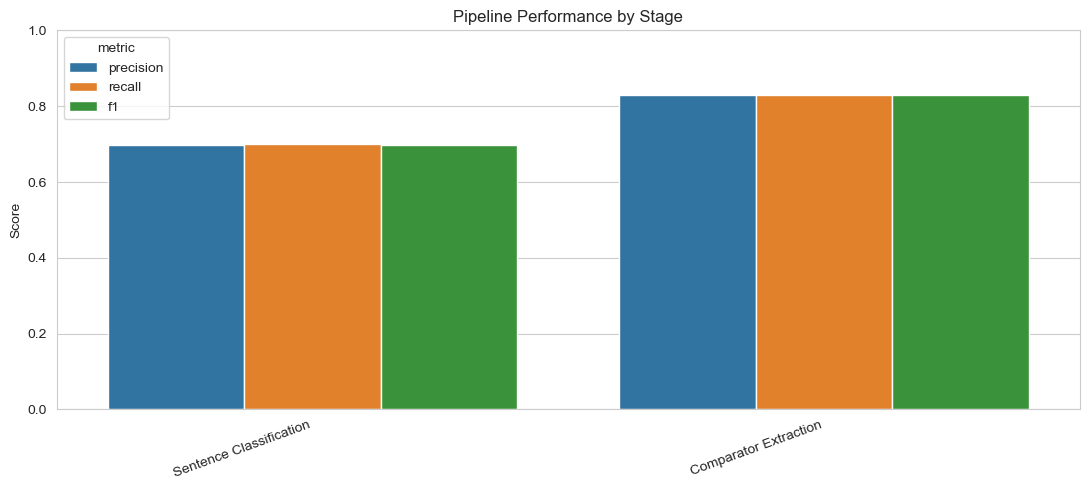

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plot_df = summary_df.melt(
    id_vars="stage",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=plot_df,
    x="stage",
    y="score",
    hue="metric",
)

plt.title("Pipeline Performance by Stage")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [13]:
def sentence_has_comparator_cue(text):
    text = normalize_text(text)
    return any(p.search(text) for p in COMPARATOR_PATTERNS)


def evaluate_comparator_proxy(doc_predictions):
    total_cue_sentences = 0
    extracted_comparator = 0
    rows = []

    for doc_id, fields in doc_predictions.items():
        for sent in fields.get("I", []):
            if sentence_has_comparator_cue(sent):
                total_cue_sentences += 1
                pred_comp = infer_comparator(sent)

                has_prediction = pred_comp is not None and normalize_text(pred_comp) != ""
                if has_prediction:
                    extracted_comparator += 1

                rows.append(
                    {
                        "doc_id": doc_id,
                        "sentence": sent,
                        "predicted_comparator": pred_comp,
                        "has_prediction": has_prediction,
                    }
                )

    coverage = extracted_comparator / total_cue_sentences if total_cue_sentences else 0.0

    metrics_df = pd.DataFrame(
        [
            {
                "cue_sentences": total_cue_sentences,
                "comparators_extracted": extracted_comparator,
                "comparator_coverage": coverage,
            }
        ]
    )

    details_df = pd.DataFrame(rows)
    return metrics_df, details_df


## 8. Example Output


In [14]:
sample_ids = pico_table_df["doc_id"].sample(3, random_state=13).tolist()

for sample_doc_id in sample_ids:
    sample_rows = [x for x in sentence_test if x.doc_id == sample_doc_id]

    print("=" * 80)
    print("Document ID:", sample_doc_id)
    print("\nSentences:")
    for ex in sample_rows[:5]:
        print("-", " ".join(ex.tokens))

    print("\nExtracted PICO row:")
    display(pico_table_df[pico_table_df["doc_id"] == sample_doc_id])


Document ID: 1968178

Sentences:
- Effects of cuff inflation on self-recorded blood pressure .
- Changes in continuously recorded 'Finapres ' finger blood pressure in ten normotensive and seven hypertensive subjects induced by self-inflation of the cuff or just wearing the inflated cuff were studied .
- Inflating the cuff caused an instantaneous rise in systolic blood pressure of 13 and 12 mm Hg ( hypertensive and normotensive subjects , respectively ) .
- Wearing the inflated cuff did not change blood pressure .
- Thus the rise in pressure was related to the muscular activity required for cuff inflation .

Extracted PICO row:


,doc_id,Population,Intervention,Comparator,Outcome
68,1968178,None,Changes in continuously recorded 'Finapres ' f...,None,Effects of cuff inflation on self-recorded blo...


Document ID: 23114870

Sentences:
- Custom-fit minimally invasive total knee arthroplasty : effect on blood loss and early clinical outcomes .
- PURPOSE Recently , new custom-fit pin guides in total knee arthroplasty ( TKA ) have been introduced .
- Use of the guides combined with the absence of intramedullary alignment jigs may lead to reduced blood loss and improved early outcomes .
- Our aim was to evaluate blood loss and early clinical outcomes in patients undergoing minimally invasive TKA using custom-fit magnetic resonance imaging ( MRI ) -based pin guides .
- METHODS A prospective study in 80 patients was carried out .

Extracted PICO row:


,doc_id,Population,Intervention,Comparator,Outcome
115,23114870,METHODS A prospective study in 80 patients was...,"PURPOSE Recently, new custom-fit pin guides in...",None,Custom-fit minimally invasive total knee arthr...


Document ID: 20739054

Sentences:
- Eltrombopag for management of chronic immune thrombocytopenia ( RAISE ) : a 6-month , randomised , phase 3 study .
- BACKGROUND Eltrombopag is an oral thrombopoietin receptor agonist for the treatment of thrombocytopenia .
- We aimed to compare the response to once daily eltrombopag versus placebo in patients with chronic immune thrombocytopenia during a 6-month period .
- METHODS We undertook a phase 3 , double-blind , placebo-controlled study in adults with previously treated immune thrombocytopenia of more than 6 months ' duration who had baseline platelet counts lower than 30,000 per μL .
- Patients were randomly allocated ( in a 2:1 ratio ) treatment with local standard of care plus 50 mg eltrombopag or matching placebo once daily for 6 months .

Extracted PICO row:


,doc_id,Population,Intervention,Comparator,Outcome
79,20739054,Eltrombopag for management of chronic immune t...,BACKGROUND Eltrombopag is an oral thrombopoiet...,Patients were randomly allocated ( in a 2:1 ra...,Patients were assessed for response to treatme...


## 9. Evaluation Summary


In [15]:
summary_df = pd.DataFrame(
    [
        {
            "stage": "Sentence Classification",
            "precision": sentence_metrics["test_precision"],
            "recall": sentence_metrics["test_recall"],
            "f1": sentence_metrics["test_f1"],
        }
    ]
)

summary_df


,stage,precision,recall,f1
0,Sentence Classification,0.697323,0.7,0.697497


## 10. Graphs


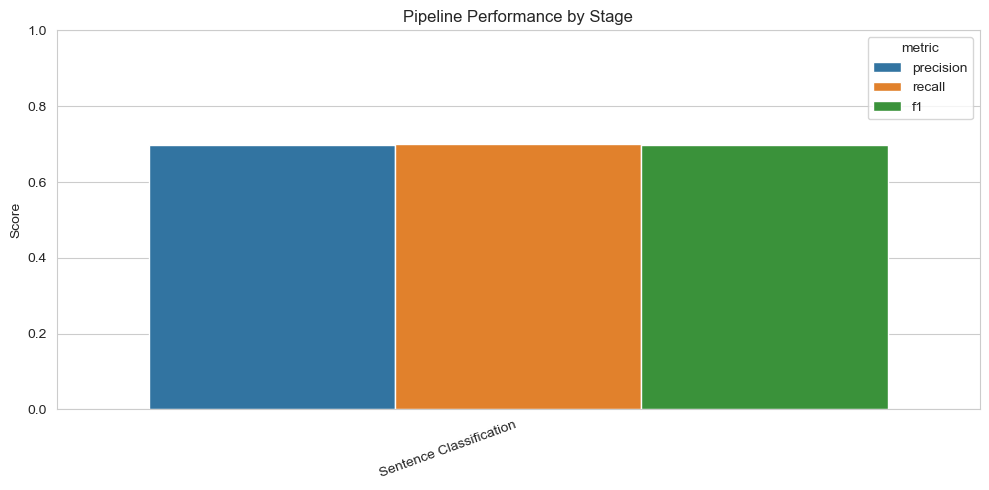

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plot_df = summary_df.melt(
    id_vars="stage",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="stage",
    y="score",
    hue="metric",
)

plt.title("Pipeline Performance by Stage")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
